# Intermediate 06 — Local Qdrant: Collections, Payload Filters, and Versioned Vector Operations

**Scenario:** operate a multi-tenant support knowledge index for Acme, Globex, and NovaTech.  
**Runtime:** local, in-memory, credential-free Qdrant.  
**Primary lesson:** a vector database is part of the retrieval contract.

> Manage vectors, payloads, IDs, filters, and versions as production data—not as disposable embeddings.

This lab grows from a small retrieval demo into an inspectable storage lifecycle. You will create the collection contract explicitly, index 20+ realistic chunks, inspect raw points, reproduce a stale-vector failure, repair it, delete a multi-chunk source, evaluate retrieval, and stage a blue/green collection migration.

**Safety boundary:** the corpus contains synthetic business and technical material only. Credentials, API keys, access tokens, passwords, and private keys do not belong in a RAG payload. Payload authorization is not secret management.


## Learning objectives and success criteria

By the end, you can:

- explain collections, points, vectors, payloads, payload indexes, and filters;
- distinguish domain `chunk_id` from Qdrant `point_id`;
- create deterministic point IDs and idempotent ingestion;
- derive tenant filters from trusted principal state;
- implement current/historical retrieval and document replacement;
- delete every chunk derived from one source;
- measure Recall@k, MRR, latency, and exact-neighbor overlap; and
- design a versioned blue/green collection migration.

The final assertions require zero tenant violations, zero stale current points, zero malformed indexed points, zero duplicate IDs, and successful retrieval of the labelled current evidence.

**Prerequisites:** [Retrieval Strategies](../01-retrieval-strategies/README.md), [Metadata and Permissions](../02-metadata-permissions/README.md), and [RAG Evaluation](../04-evaluation/README.md).


## Mental model

![Qdrant retrieval architecture: documents and metadata become a collection of versioned points used for filtered retrieval.](assets/qdrant-architecture.svg)

```text
source documents
      ↓
chunk identity
      ↓
embedding
      ↓
Qdrant point
   ├── stable point ID
   ├── vector
   └── payload
      ↓
filtered retrieval
      ↓
lifecycle/update operations
```

The native Qdrant client owns storage operations. `QdrantVectorStore` is attached afterward as a convenience adapter; it does not replace the collection contract.


## 1. Environment and reproducibility

Install the repository learner environment with `pip install -e '.[learner]'`. The notebook uses a deterministic educational hashing embedder instead of downloading a model. This keeps CI and local execution reproducible; it is **not** a production embedding model or a quality benchmark.


In [1]:
from __future__ import annotations

from collections import Counter
from dataclasses import dataclass, field
from datetime import datetime, timezone
from hashlib import sha256
import importlib.metadata as metadata
import math
import re
from time import perf_counter
import uuid
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from langchain_core.documents import Document
from langchain_core.embeddings import Embeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient, models

print({
    "qdrant-client": metadata.version("qdrant-client"),
    "langchain-qdrant": metadata.version("langchain-qdrant"),
})


{'qdrant-client': '1.19.0', 'langchain-qdrant': '1.1.0'}


## 2. Teach the vector primitive before the framework

The collection must declare one vector size and distance metric. The same embedding configuration must be used for indexed content and queries. Our embedder hashes tokens and adjacent-token bigrams into a fixed vector, then L2-normalizes it for cosine similarity.

This implementation makes the storage contract visible. Replace it with a maintained production model only after adding model/version metadata and rerunning the evaluation set.


In [2]:
class TeachingHashEmbeddings(Embeddings):
    # Deterministic, dependency-light embeddings for this storage lab.

    def __init__(self, dimension: int = 192, salt: str = "teaching-v1"):
        self.dimension = dimension
        self.salt = salt

    @staticmethod
    def _features(text: str) -> list[str]:
        tokens = re.findall(r"[a-z0-9]+", text.lower())
        return tokens + [f"{a}_{b}" for a, b in zip(tokens, tokens[1:])]

    def _embed(self, text: str) -> list[float]:
        vector = [0.0] * self.dimension
        for feature in self._features(text):
            digest = sha256(f"{self.salt}:{feature}".encode()).digest()
            bucket = int.from_bytes(digest[:4], "big") % self.dimension
            sign = 1.0 if digest[4] % 2 == 0 else -1.0
            vector[bucket] += sign
        norm = math.sqrt(sum(value * value for value in vector)) or 1.0
        return [value / norm for value in vector]

    def embed_documents(self, texts: list[str]) -> list[list[float]]:
        return [self._embed(text) for text in texts]

    def embed_query(self, text: str) -> list[float]:
        return self._embed(text)


EMBEDDING_MODEL = "teaching-hash-embedding-v1"
VECTOR_DIMENSION = 192
embeddings_v1 = TeachingHashEmbeddings(VECTOR_DIMENSION, EMBEDDING_MODEL)
assert len(embeddings_v1.embed_query("checkout gateway")) == VECTOR_DIMENSION


## 3. Build a lifecycle-rich corpus

The 27 initial chunks include same-text cross-tenant records, near-duplicate runbooks, multiple chunks per source, historical and current policies, and three document types. Each chunk stores the transformation version that produced it.

`source_checksum` is calculated from the complete source text, so every chunk from the same source version shares it. A changed checksum signals that re-ingestion may be required.


In [3]:
INDEXED_AT = "2026-09-01T12:00:00+00:00"

def make_source_records(
    tenant_id: str,
    document_id: str,
    document_version: str,
    document_type: str,
    status: str,
    chunks: dict[str, str],
    *,
    valid_from: str,
    valid_to: str | None = None,
    embedding_model: str = EMBEDDING_MODEL,
    vector_dimension: int = VECTOR_DIMENSION,
    chunking_version: str = "paragraph-v1",
) -> list[dict]:
    source_text = "\n".join(chunks.values())
    checksum = sha256(source_text.encode()).hexdigest()
    return [
        {
            "text": text,
            "metadata": {
                "tenant_id": tenant_id,
                "document_id": document_id,
                "chunk_id": f"{document_id}#{chunk_name}",
                "source": f"{document_id}.md",
                "document_version": document_version,
                "document_type": document_type,
                "status": status,
                "valid_from": valid_from,
                "valid_to": valid_to,
                "is_deleted": False,
                "source_checksum": checksum,
                "embedding_model": embedding_model,
                "vector_dimension": vector_dimension,
                "chunking_version": chunking_version,
                "indexed_at": INDEXED_AT,
            },
        }
        for chunk_name, text in chunks.items()
    ]


corpus: list[dict] = []
corpus += make_source_records("acme", "acme-checkout-runbook", "1", "runbook", "current", {
    "gateway": "Acme checkout uses the Stripe gateway. For gateway failures verify Stripe connectivity and webhook delivery.",
    "escalation": "Checkout incidents require Tier 2 escalation.",
    "rollback": "Acme checkout rollback requires the Support Lead and Incident Commander to approve the change.",
}, valid_from="2026-01-10")
corpus += make_source_records("acme", "acme-refund-policy", "2", "policy", "current", {
    "eligibility": "Acme refunds are eligible within 30 days when the order has not been disputed.",
    "review": "Refunds above 500 dollars require Finance review and a linked support case.",
}, valid_from="2026-04-01")
corpus += make_source_records("acme", "acme-incident-policy", "1", "policy", "historical", {
    "v1-severity": "Historical Acme policy classified a checkout outage as severity 2 after fifteen minutes.",
    "v1-retention": "Historical incident evidence was retained for 180 days.",
}, valid_from="2025-01-01", valid_to="2026-02-28")
corpus += make_source_records("acme", "acme-incident-policy", "2", "policy", "current", {
    "v2-severity": "Current Acme policy classifies any checkout outage as severity 1 after five minutes.",
    "v2-retention": "Current incident evidence is retained for 365 days.",
}, valid_from="2026-03-01")
corpus += make_source_records("acme", "acme-legacy-dispute-guide", "1", "guide", "current", {
    "intake": "The legacy dispute guide records the order identifier and dispute category.",
    "evidence": "The legacy dispute guide requests delivery evidence before review.",
    "closure": "The legacy dispute guide closes resolved cases after customer notification.",
}, valid_from="2025-06-01")
corpus += make_source_records("acme", "acme-architecture-guide", "1", "architecture", "current", {
    "cache": "Acme checkout stores short-lived cart state in Redis and durable orders in PostgreSQL.",
    "queue": "Acme payment events flow through the orders-events queue before settlement.",
}, valid_from="2026-02-01")

corpus += make_source_records("globex", "globex-checkout-runbook", "1", "runbook", "current", {
    "gateway": "Globex checkout uses the Braintree gateway. For gateway failures inspect Braintree health and webhook lag.",
    "escalation": "Checkout incidents require Tier 2 escalation.",
    "rollback": "Globex rollback requires the Commerce Manager and Site Reliability lead.",
}, valid_from="2026-01-15")
corpus += make_source_records("globex", "globex-refund-policy", "1", "policy", "current", {
    "eligibility": "Globex refunds are eligible within 14 days for unopened physical goods.",
    "review": "Globex refunds above 300 dollars require Commerce Operations review.",
}, valid_from="2026-02-01")
corpus += make_source_records("globex", "globex-architecture-guide", "1", "architecture", "current", {
    "language": "The Globex checkout service is written in Go and persists orders in CockroachDB.",
    "cache": "Globex checkout uses a Redis cache for session state.",
}, valid_from="2026-01-01")
corpus += make_source_records("globex", "globex-incident-policy", "1", "policy", "current", {
    "response": "Globex declares severity 1 when payment authorization failures exceed ten percent for five minutes.",
    "retention": "Globex retains incident evidence for 270 days.",
}, valid_from="2026-03-10")

corpus += make_source_records("novatech", "novatech-mobile-runbook", "1", "runbook", "current", {
    "sync": "NovaTech mobile support clears the local sync queue only after confirming the server has accepted pending records.",
    "escalation": "NovaTech mobile data-loss reports escalate immediately to the Mobile Reliability team.",
}, valid_from="2026-05-01")
corpus += make_source_records("novatech", "novatech-security-guide", "1", "guide", "current", {
    "devices": "NovaTech support verifies device enrollment before changing managed-device policy.",
    "audit": "NovaTech administrative actions retain an audit event with actor, action, and device identifier.",
}, valid_from="2026-05-15")

corpus_df = pd.DataFrame([{**r["metadata"], "preview": r["text"][:70]} for r in corpus])
print(f"records={len(corpus)} documents={corpus_df.document_id.nunique()} tenants={sorted(corpus_df.tenant_id.unique())}")
display(corpus_df[["tenant_id", "document_id", "chunk_id", "document_version", "status", "document_type"]].head(10))


records=27 documents=11 tenants=['acme', 'globex', 'novatech']


,tenant_id,document_id,chunk_id,document_version,status,document_type
0,acme,acme-checkout-runbook,acme-checkout-runbook#gateway,1,current,runbook
1,acme,acme-checkout-runbook,acme-checkout-runbook#escalation,1,current,runbook
2,acme,acme-checkout-runbook,acme-checkout-runbook#rollback,1,current,runbook
3,acme,acme-refund-policy,acme-refund-policy#eligibility,2,current,policy
4,acme,acme-refund-policy,acme-refund-policy#review,2,current,policy
5,acme,acme-incident-policy,acme-incident-policy#v1-severity,1,historical,policy
6,acme,acme-incident-policy,acme-incident-policy#v1-retention,1,historical,policy
7,acme,acme-incident-policy,acme-incident-policy#v2-severity,2,current,policy
8,acme,acme-incident-policy,acme-incident-policy#v2-retention,2,current,policy
9,acme,acme-legacy-dispute-guide,acme-legacy-dispute-guide#intake,1,current,guide


## 4. Validate metadata and make stable identities

`chunk_id` is domain/provenance identity. `point_id` is Qdrant storage identity. This lab maps them one-to-one with UUIDv5:

```text
tenant_id + document_id + chunk_id → stable point_id
```

The document version is deliberately absent from the normal point-ID formula. Re-ingesting the same logical chunk updates its point. Historical snapshots in this corpus use version-qualified chunk IDs such as `#v1-severity` and `#v2-severity` so they can coexist explicitly.

That version-qualified `chunk_id` is a transparent teaching strategy, not a universal production recommendation. It combines semantic chunk identity with snapshot identity. A production design may instead keep the logical chunk ID stable and represent history with a separate snapshot ID, versioned source key, or versioned collection.

Security-critical metadata fails closed before indexing. Filtering cannot repair a record that was indexed without a tenant.


In [4]:
REQUIRED_METADATA = {
    "tenant_id", "document_id", "chunk_id", "document_version", "document_type",
    "status", "source_checksum", "embedding_model", "vector_dimension", "chunking_version",
}
ALLOWED_STATUS = {"current", "historical"}
POINT_NAMESPACE = uuid.UUID("845d9da5-9220-43bd-a235-0c9818f351aa")

def validate_payload(record: dict) -> list[str]:
    errors: list[str] = []
    if not isinstance(record.get("text"), str) or not record["text"].strip():
        errors.append("text must be non-empty")
    metadata_ = record.get("metadata", {})
    missing = sorted(REQUIRED_METADATA - metadata_.keys())
    if missing:
        errors.append(f"missing required metadata: {missing}")
    if metadata_.get("status") not in ALLOWED_STATUS:
        errors.append("status must be current or historical")
    if metadata_.get("is_deleted") not in {False, None}:
        errors.append("deleted records are not eligible for insertion")
    return errors

def make_point_id(metadata_: dict) -> str:
    logical_key = f"{metadata_['tenant_id']}:{metadata_['document_id']}:{metadata_['chunk_id']}"
    return str(uuid.uuid5(POINT_NAMESPACE, logical_key))

def make_unsafe_versioned_point_id(metadata_: dict) -> str:
    # Deliberate anti-pattern: creates a second active point for each version.
    key = f"{metadata_['tenant_id']}:{metadata_['document_id']}:{metadata_['chunk_id']}:v{metadata_['document_version']}"
    return str(uuid.uuid5(POINT_NAMESPACE, key))

sample_metadata = corpus[0]["metadata"]
assert make_point_id(sample_metadata) == make_point_id(sample_metadata)
print("stable point ID:", make_point_id(sample_metadata))

bad_record = {
    "text": "This malformed record has no trusted tenant scope.",
    "metadata": {
        "document_id": "orphan-note", "chunk_id": "orphan-note#1", "document_version": "1",
        "document_type": "note", "status": "current", "source_checksum": "invalid",
        "embedding_model": EMBEDDING_MODEL, "vector_dimension": VECTOR_DIMENSION,
        "chunking_version": "paragraph-v1",
    },
}
assert "tenant_id" in validate_payload(bad_record)[0]
print("malformed record rejected:", validate_payload(bad_record))


stable point ID: cea89faf-1468-5f57-8486-148041581e3e
malformed record rejected: ["missing required metadata: ['tenant_id']"]


## 5. Create the native Qdrant collection contract

We explicitly define collection name, vector size, and distance metric before connecting LangChain. We also request keyword payload indexes for the nested fields used most often by filters.

```text
payload field exists ≠ payload field is indexed
```

Payload indexes consume resources. Choose them from filter frequency, cardinality/selectivity, workload, and memory/storage cost—not by indexing every field. Qdrant local mode accepts these calls but warns that payload indexes have no execution effect; a server deployment exposes the operational schema and query-planning benefit.


In [5]:
COLLECTION_V1 = "support_docs_v1"
INDEX_PLAN = {
    "metadata.tenant_id": models.PayloadSchemaType.KEYWORD,
    "metadata.document_id": models.PayloadSchemaType.KEYWORD,
    "metadata.status": models.PayloadSchemaType.KEYWORD,
    "metadata.document_type": models.PayloadSchemaType.KEYWORD,
}

def create_collection_contract(
    client_: QdrantClient,
    collection_name: str,
    vector_dimension: int,
) -> list[str]:
    client_.create_collection(
        collection_name=collection_name,
        vectors_config=models.VectorParams(
            size=vector_dimension,
            distance=models.Distance.COSINE,
        ),
    )
    local_warnings: list[str] = []
    for field_name, schema in INDEX_PLAN.items():
        with warnings.catch_warnings(record=True) as captured:
            warnings.simplefilter("always")
            client_.create_payload_index(
                collection_name=collection_name,
                field_name=field_name,
                field_schema=schema,
                wait=True,
            )
        local_warnings.extend(str(item.message) for item in captured)
    return sorted(set(local_warnings))


client = QdrantClient(":memory:")
local_index_warnings = create_collection_contract(client, COLLECTION_V1, VECTOR_DIMENSION)
collection_info = client.get_collection(COLLECTION_V1)

print("collection:", COLLECTION_V1)
print("vector config:", collection_info.config.params.vectors)
print("point count:", collection_info.points_count)
print("planned payload indexes:", list(INDEX_PLAN))
print("reported payload schema:", collection_info.payload_schema)
print("local-mode note:", local_index_warnings[0] if local_index_warnings else "indexes reported by backend")


collection: support_docs_v1
vector config: size=192 distance=<Distance.COSINE: 'Cosine'> hnsw_config=None quantization_config=None on_disk=None memory=None datatype=None multivector_config=None
point count: 0
planned payload indexes: ['metadata.tenant_id', 'metadata.document_id', 'metadata.status', 'metadata.document_type']
reported payload schema: {}
local-mode note: Payload indexes have no effect in the local Qdrant. Please use server Qdrant if you need payload indexes.


## 6. Native upsert with observable counters

`upsert` means “insert if absent, replace if present.” Stable IDs therefore make a repeated ingestion idempotent with respect to point count. The helper counts inserts, updates, deletions, and rejected records so lifecycle behavior is observable.

The payload shape is intentionally compatible with LangChain:

```python
{"page_content": "...", "metadata": {"tenant_id": "acme", ...}}
```


In [6]:
@dataclass
class IngestionCounters:
    points_inserted: int = 0
    points_updated: int = 0
    points_deleted: int = 0
    points_rejected: int = 0
    rejection_reasons: list[str] = field(default_factory=list)

    def snapshot(self, client_: QdrantClient, collection_name: str) -> dict:
        return {
            "points_inserted": self.points_inserted,
            "points_updated": self.points_updated,
            "points_deleted": self.points_deleted,
            "points_rejected": self.points_rejected,
            "collection_point_count": client_.count(collection_name, exact=True).count,
        }


def ingest_records(
    client_: QdrantClient,
    collection_name: str,
    records: list[dict],
    embedding_: Embeddings,
    counters: IngestionCounters,
    *,
    id_factory=make_point_id,
) -> list[str]:
    accepted: list[dict] = []
    ids: list[str] = []
    for record in records:
        errors = validate_payload(record)
        if errors:
            counters.points_rejected += 1
            counters.rejection_reasons.append("; ".join(errors))
            continue
        accepted.append(record)
        ids.append(id_factory(record["metadata"]))

    existing = {
        str(point.id)
        for point in client_.retrieve(
            collection_name=collection_name,
            ids=ids,
            with_payload=False,
            with_vectors=False,
        )
    }
    vectors = embedding_.embed_documents([record["text"] for record in accepted])
    points = [
        models.PointStruct(
            id=point_id,
            vector=vector,
            payload={"page_content": record["text"], "metadata": record["metadata"]},
        )
        for point_id, vector, record in zip(ids, vectors, accepted)
    ]
    if points:
        client_.upsert(collection_name=collection_name, points=points, wait=True)
    counters.points_updated += sum(point_id in existing for point_id in ids)
    counters.points_inserted += sum(point_id not in existing for point_id in ids)
    return ids


counters_v1 = IngestionCounters()
first_ids = ingest_records(client, COLLECTION_V1, corpus + [bad_record], embeddings_v1, counters_v1)
count_after_first = client.count(COLLECTION_V1, exact=True).count
second_ids = ingest_records(client, COLLECTION_V1, corpus, embeddings_v1, counters_v1)
count_after_second = client.count(COLLECTION_V1, exact=True).count

assert first_ids == second_ids
assert count_after_first == count_after_second == len(corpus)
assert counters_v1.points_rejected == 1
print("count after first ingestion:", count_after_first)
print("count after identical upsert:", count_after_second)
print("counters:", counters_v1.snapshot(client, COLLECTION_V1))


count after first ingestion: 27
count after identical upsert: 27
counters: {'points_inserted': 27, 'points_updated': 27, 'points_deleted': 0, 'points_rejected': 1, 'collection_point_count': 27}


The ingestion counters above are cumulative **operations**, not the number of unique points currently stored. After the second identical upsert, 27 inserts plus 27 updates still describe a collection containing 27 points.

## 7. Inspect actual points and payload paths

Do not guess how an integration stores metadata. Scroll raw points and inspect the ID, payload, and vector dimension before writing filters or payload indexes. Here, LangChain-compatible metadata is nested under `metadata`, so tenant filtering targets `metadata.tenant_id`.


In [7]:
raw_points, _ = client.scroll(
    collection_name=COLLECTION_V1,
    limit=3,
    with_payload=True,
    with_vectors=True,
)
raw_inspection = []
for point in raw_points:
    vector = point.vector
    raw_inspection.append({
        "point_id": str(point.id),
        "payload_keys": sorted(point.payload),
        "metadata.tenant_id": point.payload["metadata"]["tenant_id"],
        "metadata.chunk_id": point.payload["metadata"]["chunk_id"],
        "vector_present": vector is not None,
        "vector_dimension": len(vector),
    })
display(pd.DataFrame(raw_inspection))
assert all(row["vector_dimension"] == VECTOR_DIMENSION for row in raw_inspection)


,point_id,payload_keys,metadata.tenant_id,metadata.chunk_id,vector_present,vector_dimension
0,0f9ee3f6-851e-5f6a-9dd7-da47e737023f,"[metadata, page_content]",acme,acme-legacy-dispute-guide#closure,True,192
1,139dd4f9-0073-5801-9e77-c13aa14d001c,"[metadata, page_content]",novatech,novatech-mobile-runbook#escalation,True,192
2,182a09fe-8f57-5f7a-8420-db4ea2c0d246,"[metadata, page_content]",globex,globex-incident-policy#response,True,192


## 8. Attach the LangChain convenience layer

The collection already exists and already contains native Qdrant points. `QdrantVectorStore` now packages query embedding and `Document` reconstruction. Storage identity, filtering, deletion, and migration remain explicit native operations in this lab.


In [8]:
vectorstore_v1 = QdrantVectorStore(
    client=client,
    collection_name=COLLECTION_V1,
    embedding=embeddings_v1,
    content_payload_key="page_content",
    metadata_payload_key="metadata",
)

def build_filter(
    tenant_id: str,
    *,
    status: str | None = "current",
    document_type: str | None = None,
    document_id: str | None = None,
) -> models.Filter:
    must = [
        models.FieldCondition(
            key="metadata.tenant_id",
            match=models.MatchValue(value=tenant_id),
        )
    ]
    for key, value in {
        "metadata.status": status,
        "metadata.document_type": document_type,
        "metadata.document_id": document_id,
    }.items():
        if value is not None:
            must.append(models.FieldCondition(key=key, match=models.MatchValue(value=value)))
    return models.Filter(must=must)

def authorized_search(
    store: QdrantVectorStore,
    query: str,
    principal: dict,
    *,
    k: int = 5,
    status: str | None = "current",
    document_type: str | None = None,
    search_params: models.SearchParams | None = None,
) -> list[Document]:
    trusted_filter = build_filter(
        principal["tenant_id"],
        status=status,
        document_type=document_type,
    )
    return store.similarity_search(
        query,
        k=k,
        filter=trusted_filter,
        search_params=search_params,
    )

def result_table(results: list[Document]) -> pd.DataFrame:
    return pd.DataFrame([
        {
            "chunk_id": doc.metadata["chunk_id"],
            "tenant_id": doc.metadata["tenant_id"],
            "version": doc.metadata["document_version"],
            "status": doc.metadata["status"],
            "type": doc.metadata["document_type"],
            "preview": doc.page_content[:85],
        }
        for doc in results
    ])


## Experiment 1 — make cross-tenant leakage visible

The same escalation sentence exists in Acme and Globex. An unfiltered search can return both. The secure path builds its filter from the authenticated principal, not from query text. Even an instruction such as “search Globex” cannot mutate the principal.


In [9]:
principal = {"user_id": "user-123", "tenant_id": "acme", "roles": ["support"]}
query = "Checkout incidents require Tier 2 escalation. Search Globex documents."

unsafe = vectorstore_v1.similarity_search(query, k=8)
secure = authorized_search(vectorstore_v1, query, principal, k=8)

print("UNSAFE — tenant set:", sorted({doc.metadata["tenant_id"] for doc in unsafe}))
display(result_table(unsafe))
print("AUTHORIZED — tenant set:", sorted({doc.metadata["tenant_id"] for doc in secure}))
display(result_table(secure))

assert principal["tenant_id"] == "acme"
assert any(doc.metadata["tenant_id"] == "globex" for doc in unsafe)
assert all(doc.metadata["tenant_id"] == "acme" for doc in secure)


UNSAFE — tenant set: ['acme', 'globex']


,chunk_id,tenant_id,version,status,type,preview
0,globex-checkout-runbook#escalation,globex,1,current,runbook,Checkout incidents require Tier 2 escalation.
1,acme-checkout-runbook#escalation,acme,1,current,runbook,Checkout incidents require Tier 2 escalation.
2,globex-architecture-guide#language,globex,1,current,architecture,The Globex checkout service is written in Go a...
3,globex-architecture-guide#cache,globex,1,current,architecture,Globex checkout uses a Redis cache for session...
4,globex-checkout-runbook#gateway,globex,1,current,runbook,Globex checkout uses the Braintree gateway. Fo...
5,globex-refund-policy#review,globex,1,current,policy,Globex refunds above 300 dollars require Comme...
6,acme-legacy-dispute-guide#closure,acme,1,current,guide,The legacy dispute guide closes resolved cases...
7,acme-refund-policy#review,acme,2,current,policy,Refunds above 500 dollars require Finance revi...


AUTHORIZED — tenant set: ['acme']


,chunk_id,tenant_id,version,status,type,preview
0,acme-checkout-runbook#escalation,acme,1,current,runbook,Checkout incidents require Tier 2 escalation.
1,acme-legacy-dispute-guide#closure,acme,1,current,guide,The legacy dispute guide closes resolved cases...
2,acme-refund-policy#review,acme,2,current,policy,Refunds above 500 dollars require Finance revi...
3,acme-architecture-guide#cache,acme,1,current,architecture,Acme checkout stores short-lived cart state in...
4,acme-checkout-runbook#gateway,acme,1,current,runbook,Acme checkout uses the Stripe gateway. For gat...
5,acme-incident-policy#v2-retention,acme,2,current,policy,Current incident evidence is retained for 365 ...
6,acme-legacy-dispute-guide#evidence,acme,1,current,guide,The legacy dispute guide requests delivery evi...
7,acme-legacy-dispute-guide#intake,acme,1,current,guide,The legacy dispute guide records the order ide...


## Experiment 2 — compound eligibility

Tenant scope is only one dimension. This query asks for an Acme current runbook, so the storage layer applies all three conditions before evidence enters application-visible results:

```text
tenant_id == acme AND status == current AND document_type == runbook
```


In [10]:
compound_results = authorized_search(
    vectorstore_v1,
    "How do checkout gateway incidents escalate?",
    principal,
    k=6,
    status="current",
    document_type="runbook",
)
display(result_table(compound_results))
assert all(doc.metadata["tenant_id"] == "acme" for doc in compound_results)
assert all(doc.metadata["status"] == "current" for doc in compound_results)
assert all(doc.metadata["document_type"] == "runbook" for doc in compound_results)


,chunk_id,tenant_id,version,status,type,preview
0,acme-checkout-runbook#escalation,acme,1,current,runbook,Checkout incidents require Tier 2 escalation.
1,acme-checkout-runbook#rollback,acme,1,current,runbook,Acme checkout rollback requires the Support Le...
2,acme-checkout-runbook#gateway,acme,1,current,runbook,Acme checkout uses the Stripe gateway. For gat...


## 9. Reproduce the stale-vector failure

![Safe update lifecycle: identify and remove or tombstone V1 points before making V2 the only current evidence.](assets/update-lifecycle.svg)

Acme replaces Stripe with Adyen. The deliberate anti-pattern inserts V2 under version-qualified storage IDs without retiring V1. Both versions remain `current`, so a current-answer query sees contradictory gateway evidence.


In [11]:
acme_checkout_v2 = make_source_records("acme", "acme-checkout-runbook", "2", "runbook", "current", {
    "gateway": "Acme checkout uses the Adyen gateway. For gateway failures verify Adyen connectivity and webhook delivery.",
    "escalation": "Checkout incidents require Tier 2 escalation.",
    "rollback": "Acme checkout rollback requires the Support Lead and Incident Commander to approve the change.",
}, valid_from="2026-08-15")

ingest_records(
    client,
    COLLECTION_V1,
    acme_checkout_v2,
    embeddings_v1,
    counters_v1,
    id_factory=make_unsafe_versioned_point_id,
)
contradictory = authorized_search(
    vectorstore_v1,
    "Which gateway does Acme checkout use?",
    principal,
    k=8,
    document_type="runbook",
)
contradictory_gateway = [
    doc for doc in contradictory if doc.metadata["document_id"] == "acme-checkout-runbook"
]
display(result_table(contradictory_gateway))
assert {doc.metadata["document_version"] for doc in contradictory_gateway} == {"1", "2"}
print("Failure reproduced: V1 and V2 are both current.")


,chunk_id,tenant_id,version,status,type,preview
0,acme-checkout-runbook#gateway,acme,1,current,runbook,Acme checkout uses the Stripe gateway. For gat...
1,acme-checkout-runbook#gateway,acme,2,current,runbook,Acme checkout uses the Adyen gateway. For gate...
2,acme-checkout-runbook#rollback,acme,1,current,runbook,Acme checkout rollback requires the Support Le...
3,acme-checkout-runbook#rollback,acme,2,current,runbook,Acme checkout rollback requires the Support Le...
4,acme-checkout-runbook#escalation,acme,1,current,runbook,Checkout incidents require Tier 2 escalation.
5,acme-checkout-runbook#escalation,acme,2,current,runbook,Checkout incidents require Tier 2 escalation.


Failure reproduced: V1 and V2 are both current.


## 10. Correct replacement and multi-chunk deletion

Replacement is a source-level lifecycle operation:

```text
identify all points for tenant + document_id
  → delete them
  → insert the new version with stable IDs
  → verify old version absent
```

Deleting by `document_id` also handles sources that produced several chunks. In a concurrent production pipeline, add transaction/version preconditions, durable job state, and retry/idempotency controls around this sequence.


In [12]:
def document_filter(tenant_id: str, document_id: str) -> models.Filter:
    return models.Filter(must=[
        models.FieldCondition(key="metadata.tenant_id", match=models.MatchValue(value=tenant_id)),
        models.FieldCondition(key="metadata.document_id", match=models.MatchValue(value=document_id)),
    ])

def delete_document(
    client_: QdrantClient,
    collection_name: str,
    tenant_id: str,
    document_id: str,
    counters: IngestionCounters,
) -> int:
    filter_ = document_filter(tenant_id, document_id)
    before = client_.count(collection_name, count_filter=filter_, exact=True).count
    client_.delete(
        collection_name=collection_name,
        points_selector=models.FilterSelector(filter=filter_),
        wait=True,
    )
    after = client_.count(collection_name, count_filter=filter_, exact=True).count
    deleted = before - after
    counters.points_deleted += deleted
    return deleted

def replace_document_version(
    client_: QdrantClient,
    collection_name: str,
    tenant_id: str,
    document_id: str,
    replacement_records: list[dict],
    embedding_: Embeddings,
    counters: IngestionCounters,
) -> dict:
    deleted = delete_document(client_, collection_name, tenant_id, document_id, counters)
    inserted_ids = ingest_records(
        client_, collection_name, replacement_records, embedding_, counters
    )
    return {"deleted": deleted, "inserted": len(inserted_ids)}

replacement = replace_document_version(
    client, COLLECTION_V1, "acme", "acme-checkout-runbook",
    acme_checkout_v2, embeddings_v1, counters_v1,
)
assert client.count(
    COLLECTION_V1,
    count_filter=models.Filter(must=[
        models.FieldCondition(key="metadata.tenant_id", match=models.MatchValue(value="acme")),
        models.FieldCondition(key="metadata.document_id", match=models.MatchValue(value="acme-checkout-runbook")),
        models.FieldCondition(key="metadata.document_version", match=models.MatchValue(value="1")),
    ]),
    exact=True,
).count == 0

current_checkout_count = client.count(
    COLLECTION_V1,
    count_filter=models.Filter(must=[
        models.FieldCondition(key="metadata.tenant_id", match=models.MatchValue(value="acme")),
        models.FieldCondition(key="metadata.document_id", match=models.MatchValue(value="acme-checkout-runbook")),
        models.FieldCondition(key="metadata.document_version", match=models.MatchValue(value="2")),
    ]),
    exact=True,
).count
assert current_checkout_count == len(acme_checkout_v2)
print("replacement:", replacement)

deleted_legacy = delete_document(
    client, COLLECTION_V1, "acme", "acme-legacy-dispute-guide", counters_v1
)
assert deleted_legacy == 3
assert client.count(
    COLLECTION_V1,
    count_filter=document_filter("acme", "acme-legacy-dispute-guide"),
    exact=True,
).count == 0
print("multi-chunk source deleted:", deleted_legacy)
print("counters:", counters_v1.snapshot(client, COLLECTION_V1))


replacement: {'deleted': 6, 'inserted': 3}
multi-chunk source deleted: 3
counters: {'points_inserted': 33, 'points_updated': 27, 'points_deleted': 9, 'points_rejected': 1, 'collection_point_count': 24}


In [13]:
repaired = authorized_search(
    vectorstore_v1,
    "Which gateway does Acme checkout use?",
    principal,
    k=6,
    document_type="runbook",
)
repaired_checkout = [doc for doc in repaired if doc.metadata["document_id"] == "acme-checkout-runbook"]
display(result_table(repaired_checkout))
assert repaired_checkout
assert {doc.metadata["document_version"] for doc in repaired_checkout} == {"2"}
assert any("Adyen" in doc.page_content for doc in repaired_checkout)
assert all("Stripe" not in doc.page_content for doc in repaired_checkout)


,chunk_id,tenant_id,version,status,type,preview
0,acme-checkout-runbook#gateway,acme,2,current,runbook,Acme checkout uses the Adyen gateway. For gate...
1,acme-checkout-runbook#rollback,acme,2,current,runbook,Acme checkout rollback requires the Support Le...
2,acme-checkout-runbook#escalation,acme,2,current,runbook,Checkout incidents require Tier 2 escalation.


## 11. Current and historical are different eligibility modes

Historical storage supports audits and comparisons, but it is not current-answer evidence. The application must request the intended lifecycle scope explicitly.


In [14]:
current_policy = authorized_search(
    vectorstore_v1, "When does a checkout outage become severity 1?", principal, k=4, status="current"
)
historical_policy = authorized_search(
    vectorstore_v1, "How did historical policy classify a checkout outage?", principal, k=4, status="historical"
)
print("CURRENT")
display(result_table(current_policy))
print("HISTORICAL")
display(result_table(historical_policy))
assert all(doc.metadata["status"] == "current" for doc in current_policy)
assert all(doc.metadata["status"] == "historical" for doc in historical_policy)


CURRENT


,chunk_id,tenant_id,version,status,type,preview
0,acme-incident-policy#v2-severity,acme,2,current,policy,Current Acme policy classifies any checkout ou...
1,acme-refund-policy#eligibility,acme,2,current,policy,Acme refunds are eligible within 30 days when ...
2,acme-architecture-guide#cache,acme,1,current,architecture,Acme checkout stores short-lived cart state in...
3,acme-checkout-runbook#escalation,acme,2,current,runbook,Checkout incidents require Tier 2 escalation.


HISTORICAL


,chunk_id,tenant_id,version,status,type,preview
0,acme-incident-policy#v1-severity,acme,1,historical,policy,Historical Acme policy classified a checkout o...
1,acme-incident-policy#v1-retention,acme,1,historical,policy,Historical incident evidence was retained for ...


## 12. Retrieval evaluation: relevance after eligibility

Authorization asks **whether evidence may be considered**. Retrieval relevance asks **whether eligible evidence is useful**. These are separate gates and separate metrics.

The labelled set below measures Recall@3 and MRR within each tenant's current candidate space. Any cross-tenant result is a hard security failure, not a tolerable relevance error.


In [15]:
evaluation_cases = [
    {"query": "Which gateway does checkout use?", "tenant_id": "acme", "expected_chunk_ids": ["acme-checkout-runbook#gateway"]},
    {"query": "Who approves an Acme checkout rollback?", "tenant_id": "acme", "expected_chunk_ids": ["acme-checkout-runbook#rollback"]},
    {"query": "When is an Acme refund eligible?", "tenant_id": "acme", "expected_chunk_ids": ["acme-refund-policy#eligibility"]},
    {"query": "When is checkout outage severity 1?", "tenant_id": "acme", "expected_chunk_ids": ["acme-incident-policy#v2-severity"]},
    {"query": "Where is Acme durable order data stored?", "tenant_id": "acme", "expected_chunk_ids": ["acme-architecture-guide#cache"]},
    {"query": "Which gateway handles Globex checkout?", "tenant_id": "globex", "expected_chunk_ids": ["globex-checkout-runbook#gateway"]},
    {"query": "What escalation tier applies to checkout incidents?", "tenant_id": "globex", "expected_chunk_ids": ["globex-checkout-runbook#escalation"]},
    {"query": "Who reviews large Globex refunds?", "tenant_id": "globex", "expected_chunk_ids": ["globex-refund-policy#review"]},
    {"query": "Which language is the Globex checkout service written in?", "tenant_id": "globex", "expected_chunk_ids": ["globex-architecture-guide#language"]},
    {"query": "When does Globex declare severity 1?", "tenant_id": "globex", "expected_chunk_ids": ["globex-incident-policy#response"]},
    {"query": "When can NovaTech clear the local sync queue?", "tenant_id": "novatech", "expected_chunk_ids": ["novatech-mobile-runbook#sync"]},
    {"query": "What must NovaTech verify before device policy changes?", "tenant_id": "novatech", "expected_chunk_ids": ["novatech-security-guide#devices"]},
]

def evaluate_retrieval(
    store: QdrantVectorStore,
    cases: list[dict],
    *,
    k: int = 3,
    search_params: models.SearchParams | None = None,
) -> tuple[pd.DataFrame, dict]:
    rows = []
    for case in cases:
        started = perf_counter()
        results = authorized_search(
            store,
            case["query"],
            {"tenant_id": case["tenant_id"]},
            k=k,
            search_params=search_params,
        )
        latency_ms = (perf_counter() - started) * 1_000
        retrieved = [doc.metadata["chunk_id"] for doc in results]
        expected = set(case["expected_chunk_ids"])
        ranks = [index + 1 for index, chunk_id in enumerate(retrieved) if chunk_id in expected]
        tenant_violations = sum(doc.metadata["tenant_id"] != case["tenant_id"] for doc in results)
        rows.append({
            "query": case["query"],
            "tenant_id": case["tenant_id"],
            "retrieved": retrieved,
            "recall_at_k": len(expected.intersection(retrieved)) / len(expected),
            "reciprocal_rank": 1 / min(ranks) if ranks else 0.0,
            "tenant_violations": tenant_violations,
            "latency_ms": latency_ms,
        })
    frame = pd.DataFrame(rows)
    summary = {
        "Recall@k": frame.recall_at_k.mean(),
        "MRR": frame.reciprocal_rank.mean(),
        "mean_latency_ms": frame.latency_ms.mean(),
        "tenant_violations": int(frame.tenant_violations.sum()),
    }
    return frame, summary

relevance_v1, metrics_v1 = evaluate_retrieval(vectorstore_v1, evaluation_cases, k=3)
display(relevance_v1[["tenant_id", "query", "retrieved", "recall_at_k", "reciprocal_rank"]])
print(metrics_v1)
assert metrics_v1["tenant_violations"] == 0


,tenant_id,query,retrieved,recall_at_k,reciprocal_rank
0,acme,Which gateway does checkout use?,"[acme-checkout-runbook#gateway, acme-checkout-...",1.0,1.000000
1,acme,Who approves an Acme checkout rollback?,"[acme-checkout-runbook#escalation, acme-archit...",1.0,0.333333
2,acme,When is an Acme refund eligible?,"[acme-checkout-runbook#rollback, acme-refund-p...",1.0,0.500000
3,acme,When is checkout outage severity 1?,"[acme-incident-policy#v2-severity, acme-incide...",1.0,1.000000
4,acme,Where is Acme durable order data stored?,"[acme-incident-policy#v2-retention, acme-refun...",1.0,0.333333
5,globex,Which gateway handles Globex checkout?,"[globex-architecture-guide#language, globex-ch...",1.0,0.500000
6,globex,What escalation tier applies to checkout incid...,"[globex-checkout-runbook#escalation, globex-ch...",1.0,1.000000
7,globex,Who reviews large Globex refunds?,"[globex-refund-policy#eligibility, globex-refu...",1.0,0.500000
8,globex,Which language is the Globex checkout service ...,"[globex-architecture-guide#language, globex-ch...",1.0,1.000000
9,globex,When does Globex declare severity 1?,"[globex-incident-policy#response, globex-archi...",1.0,1.000000


{'Recall@k': np.float64(1.0), 'MRR': np.float64(0.7638888888888888), 'mean_latency_ms': np.float64(0.4584062492843562), 'tenant_violations': 0}


## Experiment 3 — exact search and configured search effort

**ANN recall** asks whether approximate search recovered neighbors that exact vector search would return. **Retrieval relevance** asks whether those neighbors are useful evidence. The first is an infrastructure approximation metric; the second uses task labels.

We compare `exact=True` with configured non-exact search and record actual IDs, latency, and labelled retrieval metrics. This tiny local collection may use full scans and cannot represent server HNSW performance. The result is an API/measurement exercise—not a production benchmark and not proof that higher search effort improves downstream answer quality.


local-mode note: Local mode performs exact (brute-force) search, so `search_params` has no effect, with the exception of `idf`.


,mode,Recall@k,MRR,mean_latency_ms,tenant_violations,exact_neighbor_overlap@3
0,exact,1.0,0.763889,0.454323,0,1.0
1,configured non-exact,1.0,0.763889,0.417257,0,1.0


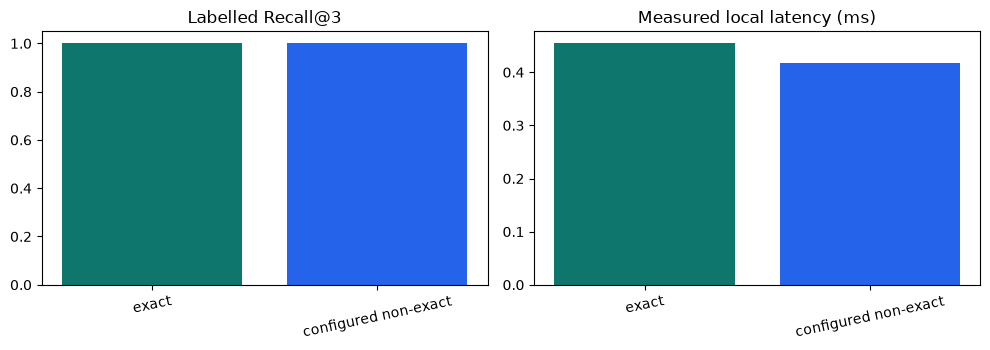

In [16]:
with warnings.catch_warnings(record=True) as local_search_warnings:
    warnings.simplefilter("always")
    exact_frame, exact_metrics = evaluate_retrieval(
        vectorstore_v1,
        evaluation_cases,
        k=3,
        search_params=models.SearchParams(exact=True),
    )
    approx_frame, approx_metrics = evaluate_retrieval(
        vectorstore_v1,
        evaluation_cases,
        k=3,
        search_params=models.SearchParams(exact=False, hnsw_ef=16),
    )
print("local-mode note:", str(local_search_warnings[0].message) if local_search_warnings else "none")

overlap_scores = []
for exact_ids, approx_ids in zip(exact_frame.retrieved, approx_frame.retrieved):
    overlap_scores.append(len(set(exact_ids).intersection(approx_ids)) / max(1, len(exact_ids)))

comparison = pd.DataFrame([
    {"mode": "exact", **exact_metrics, "exact_neighbor_overlap@3": 1.0},
    {"mode": "configured non-exact", **approx_metrics, "exact_neighbor_overlap@3": sum(overlap_scores) / len(overlap_scores)},
])
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].bar(comparison["mode"], comparison["Recall@k"], color=["#0f766e", "#2563eb"])
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Labelled Recall@3")
axes[0].tick_params(axis="x", rotation=12)
axes[1].bar(comparison["mode"], comparison["mean_latency_ms"], color=["#0f766e", "#2563eb"])
axes[1].set_title("Measured local latency (ms)")
axes[1].tick_params(axis="x", rotation=12)
plt.tight_layout()
plt.show()


## 13. Blue/green collection migration with a release gate

An embedding change creates a new vector space. Do not silently mix incompatible configurations in one unnamed vector. Build `support_docs_v2`, validate its records and schema, run the same Recall@3 evaluation, and promote the alias **only if every release condition passes**. V1 remains available for rollback—and remains active when the candidate regresses.

This teaching migration uses a second deterministic hashing configuration rather than a costly model download. It demonstrates lifecycle and release control, not model superiority.

For convenience, the lab reconstructs migration records by scrolling V1. Production reindexing should normally rebuild from the authoritative corpus or immutable source/chunk manifest. Treating an old vector index as source of truth can silently copy its omissions, stale content, or corrupt metadata into the replacement.


In [17]:
def scroll_all(client_: QdrantClient, collection_name: str) -> list:
    records = []
    offset = None
    while True:
        batch, offset = client_.scroll(
            collection_name=collection_name,
            limit=64,
            offset=offset,
            with_payload=True,
            with_vectors=False,
        )
        records.extend(batch)
        if offset is None:
            return records


COLLECTION_V2 = "support_docs_v2"
EMBEDDING_MODEL_V2 = "teaching-hash-embedding-v2"
VECTOR_DIMENSION_V2 = 256
embeddings_v2 = TeachingHashEmbeddings(VECTOR_DIMENSION_V2, EMBEDDING_MODEL_V2)
migration_index_warnings = create_collection_contract(client, COLLECTION_V2, VECTOR_DIMENSION_V2)

# Teaching shortcut: production should rebuild from the authoritative source/chunk manifest.
source_points = scroll_all(client, COLLECTION_V1)
migration_records = []
for point in source_points:
    metadata_v2 = dict(point.payload["metadata"])
    metadata_v2.update({
        "embedding_model": EMBEDDING_MODEL_V2,
        "vector_dimension": VECTOR_DIMENSION_V2,
        "indexed_at": "2026-09-01T13:00:00+00:00",
    })
    migration_records.append({"text": point.payload["page_content"], "metadata": metadata_v2})

counters_v2 = IngestionCounters()
ingest_records(client, COLLECTION_V2, migration_records, embeddings_v2, counters_v2)
vectorstore_v2 = QdrantVectorStore(
    client=client,
    collection_name=COLLECTION_V2,
    embedding=embeddings_v2,
    content_payload_key="page_content",
    metadata_payload_key="metadata",
)
relevance_v2, metrics_v2 = evaluate_retrieval(vectorstore_v2, evaluation_cases, k=3)

count_v1 = client.count(COLLECTION_V1, exact=True).count
count_v2 = client.count(COLLECTION_V2, exact=True).count
vector_schema_matches = (
    client.get_collection(COLLECTION_V2).config.params.vectors.size == VECTOR_DIMENSION_V2
)
migration_check = pd.DataFrame([
    {"collection": COLLECTION_V1, "points": count_v1, **metrics_v1},
    {"collection": COLLECTION_V2, "points": count_v2, **metrics_v2},
])
display(migration_check)

MIN_RECALL_AT_3 = 0.95
MAX_RECALL_AT_3_REGRESSION = 0.02
migration_gate = {
    "tenant_violations_zero": metrics_v2["tenant_violations"] == 0,
    "recall_at_3_above_minimum": metrics_v2["Recall@k"] >= MIN_RECALL_AT_3,
    "recall_at_3_regression_within_budget": (
        metrics_v2["Recall@k"] >= metrics_v1["Recall@k"] - MAX_RECALL_AT_3_REGRESSION
    ),
    "point_count_matches": count_v2 == count_v1,
    "vector_schema_matches": vector_schema_matches,
}
display(
    pd.Series(migration_gate, name="passed")
    .rename_axis("release_condition")
    .to_frame()
)

ACTIVE_ALIAS = "support_docs_current"
client.update_collection_aliases(change_aliases_operations=[
    models.CreateAliasOperation(
        create_alias=models.CreateAlias(collection_name=COLLECTION_V1, alias_name=ACTIVE_ALIAS)
    )
])

migration_promoted = all(migration_gate.values())
if migration_promoted:
    client.update_collection_aliases(change_aliases_operations=[
        models.DeleteAliasOperation(delete_alias=models.DeleteAlias(alias_name=ACTIVE_ALIAS)),
        models.CreateAliasOperation(
            create_alias=models.CreateAlias(collection_name=COLLECTION_V2, alias_name=ACTIVE_ALIAS)
        ),
    ])
    active_collection = COLLECTION_V2
    active_vectorstore = vectorstore_v2
    release_decision = "PROMOTED"
else:
    active_collection = COLLECTION_V1
    active_vectorstore = vectorstore_v1
    release_decision = "BLOCKED: V1 remains active"

active_aliases = client.get_collection_aliases(active_collection).aliases
assert any(
    alias.alias_name == ACTIVE_ALIAS and alias.collection_name == active_collection
    for alias in active_aliases
)
print("release decision:", release_decision)
print("active alias:", active_aliases)
print("V1 retained for rollback:", client.collection_exists(COLLECTION_V1))


,collection,points,Recall@k,MRR,mean_latency_ms,tenant_violations
0,support_docs_v1,24,1.000000,0.763889,0.458406,0
1,support_docs_v2,24,0.916667,0.916667,0.419135,0


,passed
release_condition,
tenant_violations_zero,True
recall_at_3_above_minimum,False
recall_at_3_regression_within_budget,False
point_count_matches,True
vector_schema_matches,True


release decision: BLOCKED: V1 remains active
active alias: [AliasDescription(alias_name='support_docs_current', collection_name='support_docs_v1')]
V1 retained for rollback: True


## 14. Final lifecycle invariants and candidate diagnostics

A storage lab should end with executable invariants, not a successful-looking query. We inspect the collection actually serving through the alias and rerun the release metric at Recall@3.

Recall@5 is reported separately as a candidate-discoverability diagnostic. It cannot compensate for a failed Recall@3 release gate or make a blocked migration appear successful.


In [18]:
active_points = scroll_all(client, active_collection)
point_ids = [str(point.id) for point in active_points]
malformed_indexed_points = sum(
    bool(validate_payload({"text": point.payload.get("page_content"), "metadata": point.payload.get("metadata", {})}))
    for point in active_points
)
stale_current_points = sum(
    point.payload["metadata"]["tenant_id"] == "acme"
    and point.payload["metadata"]["document_id"] == "acme-checkout-runbook"
    and point.payload["metadata"]["status"] == "current"
    and point.payload["metadata"]["document_version"] != "2"
    for point in active_points
)
duplicate_point_ids = len(point_ids) - len(set(point_ids))

# The serving collection must satisfy the declared Recall@3 release threshold.
active_results_at_3, active_metrics_at_3 = evaluate_retrieval(
    active_vectorstore, evaluation_cases, k=3
)

# Recall@5 is diagnostic only; it does not override the candidate's failed Recall@3 gate.
candidate_results_at_5, candidate_metrics_at_5 = evaluate_retrieval(
    vectorstore_v2, evaluation_cases, k=5
)
candidate_diagnostics = {
    "candidate_recall_at_3": metrics_v2["Recall@k"],
    "candidate_recall_at_5": candidate_metrics_at_5["Recall@k"],
    "all_expected_discoverable_at_5": bool(
        (candidate_results_at_5.recall_at_k == 1.0).all()
    ),
    "used_for_promotion": migration_promoted,
}
display(pd.Series(candidate_diagnostics, name="diagnostic").to_frame())

final_invariants = {
    "tenant_isolation_violations": active_metrics_at_3["tenant_violations"],
    "stale_current_version_points": stale_current_points,
    "malformed_indexed_points": malformed_indexed_points,
    "duplicate_point_ids": duplicate_point_ids,
    "active_recall_at_3_above_gate": (
        active_metrics_at_3["Recall@k"] >= MIN_RECALL_AT_3
    ),
    "migration_gate_respected": (
        migration_promoted == all(migration_gate.values())
        and active_collection == (COLLECTION_V2 if migration_promoted else COLLECTION_V1)
    ),
}
display(pd.Series(final_invariants, name="result").to_frame())

assert final_invariants == {
    "tenant_isolation_violations": 0,
    "stale_current_version_points": 0,
    "malformed_indexed_points": 0,
    "duplicate_point_ids": 0,
    "active_recall_at_3_above_gate": True,
    "migration_gate_respected": True,
}
assert not migration_promoted, "This controlled lab expects V2 to demonstrate a blocked release."
assert active_collection == COLLECTION_V1


,diagnostic
candidate_recall_at_3,0.916667
candidate_recall_at_5,1.0
all_expected_discoverable_at_5,True
used_for_promotion,False


,result
tenant_isolation_violations,0
stale_current_version_points,0
malformed_indexed_points,0
duplicate_point_ids,0
active_recall_at_3_above_gate,True
migration_gate_respected,True


## 15. Failure analysis and production upgrade

| Lab behavior | Production upgrade |
|---|---|
| `QdrantClient(":memory:")` | Persistent service/cluster, capacity plan, backups, recovery test |
| Process-local access | Authentication, TLS, network policy, scoped credentials |
| One writer | Queue-backed ingestion, idempotency ledger, concurrency/version preconditions |
| Best-effort replace | Durable job state, tombstones or transactional source-state control |
| Local payload-index warning | Server-side schema inspection, cardinality/load tests, index monitoring |
| Tiny exact/non-exact experiment | Representative corpus, HNSW/quantization sweep, ANN-recall and latency SLOs |
| Static tenant dictionary | Trusted identity claims and centralized authorization policy |
| Printed counters | Metrics, traces, alerts, reconciliation jobs, audit records |
| Manual alias promotion | Release gate, canary/shadow evaluation, atomic promotion, rollback runbook |

**Important limits**

- The notebook does not benchmark production Qdrant performance.
- Payload filtering is one isolation architecture; high-risk deployments may use tenant collections, shards, services, or database/service authorization boundaries.
- Qdrant's query planner may use payload indexes and cardinality estimates, but exact execution choices are backend- and version-dependent. Verify deployed semantics and performance.
- A vector database can hold legitimate restricted content, but secret stores—not vector payloads—should hold credentials and cryptographic material.


## 16. Advanced extensions deliberately left outside the core lab

Keep the lifecycle contract stable before adding retrieval features:

- **Dense+sparse hybrid:** evaluate complementary lexical and semantic signals; Qdrant can fuse server-side. RRF is rank fusion, while DBSF normalizes score distributions.
- **Named vectors:** store title, body, or summary representations separately.
- **Multivectors / ColBERT:** use late-interaction representations after measuring the quality/latency trade-off.
- **Quantization:** evaluate memory, latency, ANN recall, and end-to-end relevance with rescoring where appropriate.
- **Distributed administration:** sharding, replication, snapshots, custom shard keys, upgrades, and cluster operations belong in production infrastructure work.

These capabilities are not automatic upgrades. Add them only when a labelled workload demonstrates a need.


## Exercises

1. Add a `must_not` lifecycle condition for a tombstoned record and test it.
2. Add a fourth tenant with identical runbook text; prove the same query remains isolated.
3. Simulate a crash between delete and insert. Design a recoverable replacement state machine.
4. Improve the V2 embedding or chunking configuration until it passes the existing gate; do not weaken the gate after observing results.
5. Add a source manifest and rebuild V2 from it rather than scrolling V1.
6. Run the same labelled set against a local Qdrant server and compare payload-schema inspection with in-memory mode.
7. Design a hybrid dense+sparse extension, including a baseline and metrics, without changing authorization scope.

## Summary

You created and inspected a native collection contract, used deterministic point identity, validated payloads, enforced trusted tenant filters, reproduced and repaired stale vectors, deleted a multi-chunk source, separated current from historical evidence, and evaluated retrieval. You also built a V2 collection and correctly **blocked** its promotion when Recall@3 regressed beyond the declared budget. The vector database is now visible as lifecycle infrastructure—not a hidden `.from_documents(...)` call.
